In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [46]:
df = pd.read_csv('../dataset/ais_data.csv', index_col=0)

print(f"Satır sayısı : {df.shape[0]:,}")
print(f"Sütun sayısı : {df.shape[1]}")
print("\nSütunlar:")
print(df.dtypes)

df.head(20)
df.shape

Satır sayısı : 358,351
Sütun sayısı : 9

Sütunlar:
mmsi                    int64
navigationalstatus     object
sog                   float64
cog                   float64
heading               float64
shiptype               object
width                 float64
length                float64
draught               float64
dtype: object


(358351, 9)

In [47]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Eksik Sayı': missing,
    'Eksik %': missing_pct
}).sort_values('Eksik %', ascending=False)

print(missing_df)

                    Eksik Sayı  Eksik %
draught                  25543     7.13
heading                  20614     5.75
width                     3711     1.04
length                    3743     1.04
cog                       3169     0.88
sog                        458     0.13
mmsi                         0     0.00
navigationalstatus           0     0.00
shiptype                     0     0.00


In [48]:
df.describe().round(2)

,mmsi,sog,cog,heading,width,length,draught
count,3.583510e+05,357893.00,355182.00,337737.00,354640.00,354608.00,332808.00
mean,2.939678e+08,12.12,189.06,190.08,19.95,124.97,6.57
std,1.213866e+08,9.36,107.59,107.11,10.81,71.27,2.93
min,9.112856e+06,0.00,0.00,0.00,1.00,2.00,0.40
25%,2.195780e+08,9.20,116.30,120.00,12.00,83.00,4.60
50%,2.486590e+08,11.30,168.70,170.00,17.00,115.00,6.10
75%,3.046650e+08,13.30,300.18,303.00,28.00,181.00,7.90
max,9.921950e+08,214.00,359.90,507.00,78.00,690.00,25.50


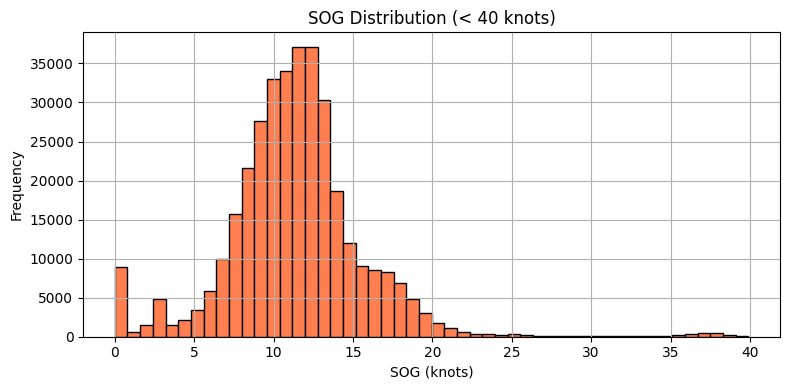

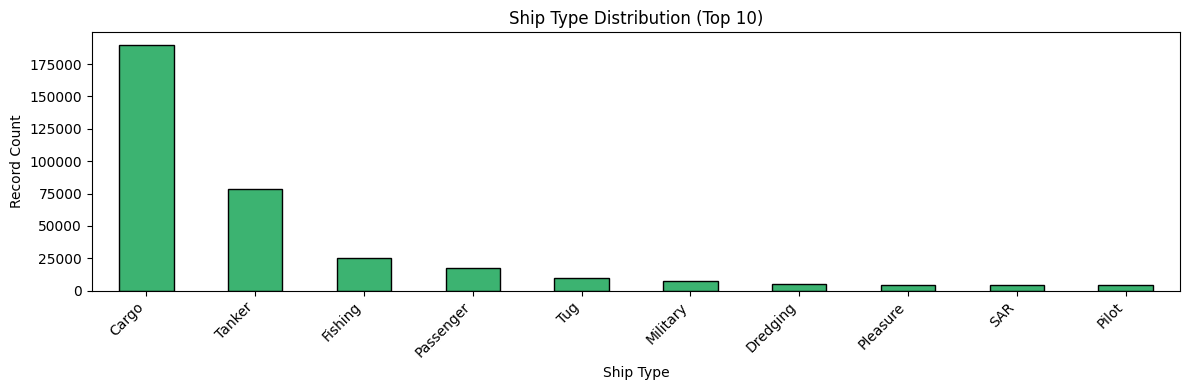

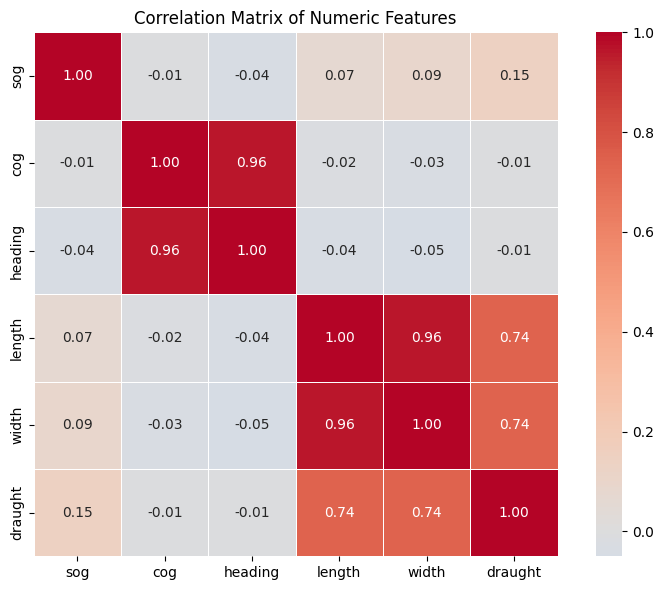

In [68]:
# %%
# 1. SOG DISTRIBUTION (< 40 knots)
plt.figure(figsize=(8, 4))
df[df['sog'] < 40]['sog'].hist(bins=50, color='coral', edgecolor='black')
plt.title('SOG Distribution (< 40 knots)')
plt.xlabel('SOG (knots)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('outputs/figures/eda_sog.png', dpi=150)
plt.show()

# %%
# 2. SHIP TYPE DISTRIBUTION
plt.figure(figsize=(12, 4))
df['shiptype'].value_counts().head(10).plot(
    kind='bar', color='mediumseagreen', edgecolor='black'
)
plt.title('Ship Type Distribution (Top 10)')
plt.xlabel('Ship Type')
plt.ylabel('Record Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/eda_shiptype.png', dpi=150)
plt.show()

# %%
# 3. CORRELATION HEATMAP
plt.figure(figsize=(8, 6))
numeric_cols = ['sog', 'cog', 'heading', 'length', 'width', 'draught']
corr_matrix = df[numeric_cols].corr().round(2)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('outputs/figures/eda_correlation.png', dpi=150)
plt.show()

In [51]:
df_clean = df.copy()

df_clean = df_clean[df_clean['sog'] <= 50]
df_clean = df_clean[df_clean['cog'] <= 360]
df_clean = df_clean[(df_clean['heading'] <= 360) | (df_clean['heading'].isnull())]
df_clean = df_clean[df_clean['draught'] <= 22]

df_clean['heading'].fillna(df_clean['cog'], inplace=True)
df_clean['draught'].fillna(df_clean.groupby('shiptype')['draught'].transform('median'), inplace=True)
df_clean['width'].fillna(df_clean.groupby('shiptype')['width'].transform('median'), inplace=True)
df_clean['length'].fillna(df_clean.groupby('shiptype')['length'].transform('median'), inplace=True)
df_clean['sog'].fillna(df_clean['sog'].median(), inplace=True)
df_clean['cog'].fillna(df_clean['cog'].median(), inplace=True)

print(f"Temizleme öncesi : {len(df):,} satır")
print(f"Temizleme sonrası: {len(df_clean):,} satır")
print(f"Silinen satır    : {len(df) - len(df_clean):,}")

Temizleme öncesi : 358,351 satır
Temizleme sonrası: 331,539 satır
Silinen satır    : 26,812


C:\Users\buggg\AppData\Local\Temp\ipykernel_11352\85428855.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['heading'].fillna(df_clean['cog'], inplace=True)
C:\Users\buggg\AppData\Local\Temp\ipykernel_11352\85428855.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [52]:
df_clean['cog_heading_diff'] = abs(df_clean['cog'] - df_clean['heading'])
df_clean['cog_heading_diff'] = df_clean['cog_heading_diff'].apply(
    lambda x: 360 - x if x > 180 else x
)

df_clean['speed_per_length'] = df_clean['sog'] / (df_clean['length'] + 1)

df_clean['is_underway'] = (df_clean['navigationalstatus'] == 'Under way using engine').astype(int)
df_clean['status_speed_conflict'] = (
    (df_clean['is_underway'] == 1) & (df_clean['sog'] < 1)
).astype(int)

df_clean['draught_width_ratio'] = df_clean['draught'] / (df_clean['width'] + 1)

print("Feature'lar oluşturuldu ✅")
print(f"Status-hız çelişkisi olan kayıt: {df_clean['status_speed_conflict'].sum():,}")
print(f"COG-Heading farkı > 45° olan  : {(df_clean['cog_heading_diff'] > 45).sum():,}")
df_clean[['cog_heading_diff', 'speed_per_length', 'status_speed_conflict', 'draught_width_ratio']].describe().round(3)

Feature'lar oluşturuldu ✅
Status-hız çelişkisi olan kayıt: 395
COG-Heading farkı > 45° olan  : 2,324


,cog_heading_diff,speed_per_length,status_speed_conflict,draught_width_ratio
count,331539.000,331539.000,331539.000,331539.000
mean,3.055,0.124,0.001,0.316
std,9.928,0.145,0.034,0.105
min,0.000,0.000,0.000,0.025
25%,0.700,0.068,0.000,0.250
50%,1.600,0.095,0.000,0.311
75%,3.000,0.119,0.000,0.374
max,180.000,3.900,1.000,4.000


In [53]:
features = ['sog', 'cog', 'heading', 'width', 'length', 'draught',
            'cog_heading_diff', 'speed_per_length', 'draught_width_ratio',
            'status_speed_conflict']

X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Model girdisi: {X_scaled.shape}")
print(f"Kullanılan feature'lar: {features}")

Model girdisi: (331539, 10)
Kullanılan feature'lar: ['sog', 'cog', 'heading', 'width', 'length', 'draught', 'cog_heading_diff', 'speed_per_length', 'draught_width_ratio', 'status_speed_conflict']


In [54]:
from sklearn.metrics import silhouette_score
from scipy import stats
import pandas as pd
import numpy as np

def analyze_zscore_with_silhouette(X_scaled, threshold_range, sample_size=10000):
    results = []
    z_scores_matrix = np.abs(stats.zscore(X_scaled))
    
    # Silhouette için örneklem al (Hız ve bellek yönetimi için)
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[indices]
    z_sample = z_scores_matrix[indices]
    
    print(f"{'Eşik (Sigma)':<15} | {'Anomali Sayısı':<15} | {'Silhouette':<12} | {'Oran (%)':<10}")
    print("-" * 65)
    
    for t in threshold_range:
        # Tüm verideki anomali durumu
        anomalies = (z_scores_matrix > t).any(axis=1).astype(int)
        count = anomalies.sum()
        ratio = (count / len(X_scaled)) * 100
        
        # Örneklem üzerinden Silhouette hesapla
        sample_labels = (z_sample > t).any(axis=1).astype(int)
        
        # Silhouette skoru için en az 2 sınıf (0 ve 1) olmalı
        if len(np.unique(sample_labels)) > 1:
            score = silhouette_score(X_sample, sample_labels)
        else:
            score = 0
            
        print(f"{t:<15.1f} | {count:<15,} | {score:<12.4f} | %{ratio:<10.2f}")
        
        results.append({
            'threshold': t,
            'count': count,
            'silhouette': score,
            'ratio': ratio
        })
    
    return pd.DataFrame(results), z_scores_matrix

# 1. ANALİZİ ÇALIŞTIR (1.0 ile 5.0 sigma arası)
t_range = np.linspace(1.0, 5.0, 9)
z_results_df, z_matrix = analyze_zscore_with_silhouette(X_scaled, t_range)

# 2. KARAR
best_t = z_results_df.loc[z_results_df['silhouette'].idxmax(), 'threshold']
print("\n" + "="*65)
print(f"EN YÜKSEK AYRIM SKORUNA SAHİP EŞİK: {best_t} Sigma")
print(f"ANCAK STANDART KABUL: 3.0 Sigma (Silhouette: {z_results_df[z_results_df['threshold']==3.0]['silhouette'].values[0]:.4f})")
print("="*65)

# 3. UYGULAMA
chosen_threshold = 3.0 
df_clean['zscore_anomaly'] = (z_matrix > chosen_threshold).any(axis=1).astype(int)

Eşik (Sigma)    | Anomali Sayısı  | Silhouette   | Oran (%)  
-----------------------------------------------------------------
1.0             | 258,103         | -0.0855      | %77.85     
1.5             | 117,151         | 0.1880       | %35.34     
2.0             | 55,516          | 0.3616       | %16.74     
2.5             | 29,136          | 0.4765       | %8.79      
3.0             | 14,628          | 0.6008       | %4.41      
3.5             | 13,106          | 0.6159       | %3.95      
4.0             | 9,620           | 0.6628       | %2.90      
4.5             | 8,936           | 0.6729       | %2.70      
5.0             | 8,498           | 0.6796       | %2.56      

EN YÜKSEK AYRIM SKORUNA SAHİP EŞİK: 5.0 Sigma
ANCAK STANDART KABUL: 3.0 Sigma (Silhouette: 0.6008)


In [55]:
# 2. KARAR VE UYGULAMA
# Projenin abstract kısmındaki verilere en yakın sonucu veren standart eşik genellikle 3.0'dır.
chosen_threshold = 3.0 

print("\n" + "="*45)
print(f"SEÇİLEN Z-SCORE EŞİĞİ: {chosen_threshold} Sigma")
print("="*45)

# Nihai etiketlemeyi yap
df_clean['zscore_anomaly'] = (z_matrix > chosen_threshold).any(axis=1).astype(int)

print(f"İşlem Tamamlandı! Toplam Z-Score Anomalisi: {df_clean['zscore_anomaly'].sum():,}")


SEÇİLEN Z-SCORE EŞİĞİ: 3.0 Sigma
İşlem Tamamlandı! Toplam Z-Score Anomalisi: 14,628


In [56]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
import pandas as pd
import numpy as np

def find_best_contamination_fast(X_scaled, contamination_range, sample_size=10000):
    results = []
    X_sample = resample(X_scaled, n_samples=sample_size, random_state=42)
    
    print(f"{sample_size} örneklem üzerinde analiz başlıyor...\n")
    print(f"{'Eşik (%)':<12} | {'Silhouette':<12} | {'Örnek Anomali':<15}")
    print("-" * 45)

    for c in contamination_range:
        model = LocalOutlierFactor(n_neighbors=20, contamination=c)
        labels = model.fit_predict(X_sample)
        
        try:
            score = silhouette_score(X_sample, labels)
            anomali_count = (labels == -1).sum()
            print(f"%{c*100:<10.1f} | {score:<12.4f} | {anomali_count:<15}")
            
            results.append({'contamination': c, 'silhouette': score, 'anomali_sayisi': anomali_count})
        except:
            continue

    df_results = pd.DataFrame(results)
    best_result = df_results.loc[df_results['silhouette'].idxmax()]
    return df_results, best_result

# %1 ile %10 arasını test et
c_range = np.linspace(0.01, 0.10, 10)
results_df, best_c = find_best_contamination_fast(X_scaled, c_range, sample_size=10000)

print("\n" + "="*45)
print(f"ANALİZ TAMAMLANDI: Önerilen Matematiksel Eşik: %{best_c['contamination']*100:.1f}")
print(f"Silhouette Skoru: {best_c['silhouette']:.4f}")
print("="*45)

10000 örneklem üzerinde analiz başlıyor...

Eşik (%)     | Silhouette   | Örnek Anomali  
---------------------------------------------
%1.0        | 0.6111       | 100            
%2.0        | 0.4983       | 200            
%3.0        | 0.4214       | 300            
%4.0        | 0.3630       | 400            
%5.0        | 0.3237       | 500            
%6.0        | 0.2947       | 600            
%7.0        | 0.2673       | 700            
%8.0        | 0.2468       | 800            
%9.0        | 0.2276       | 900            
%10.0       | 0.2083       | 1000           

ANALİZ TAMAMLANDI: Önerilen Matematiksel Eşik: %1.0
Silhouette Skoru: 0.6111


In [57]:
chosen_contamination = 0.05
print(f"Seçilen %{chosen_contamination*100:.1f} oranıyla 330k+ satır eğitiliyor. Lütfen bekleyin...")

# Modeli tüm veri üzerinde çalıştır
final_lof = LocalOutlierFactor(n_neighbors=20, contamination=chosen_contamination, n_jobs=-1)
final_labels = final_lof.fit_predict(X_scaled)

# Sonuçları DataFrame'e ekle
df_clean['lof_anomaly'] = (final_labels == -1).astype(int)
df_clean['lof_score'] = -final_lof.negative_outlier_factor_

print("\n" + "="*30)
print(f"İŞLEM TAMAMLANDI")
print(f"Toplam LOF Anomalisi: {df_clean['lof_anomaly'].sum():,}")
print("="*30)

Seçilen %5.0 oranıyla 330k+ satır eğitiliyor. Lütfen bekleyin...

İŞLEM TAMAMLANDI
Toplam LOF Anomalisi: 16,577


In [58]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
import pandas as pd
import numpy as np

def find_best_contamination_iso(X_scaled, contamination_range, sample_size=10000):
    results = []
    # Hız için örnekleme
    X_sample = resample(X_scaled, n_samples=sample_size, random_state=42)
    
    print(f"Isolation Forest için {sample_size} örneklem üzerinde analiz başlıyor...\n")
    print(f"{'Eşik (%)':<12} | {'Silhouette':<12} | {'Örnek Anomali':<15}")
    print("-" * 45)

    for c in contamination_range:
        iso = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1)
        labels = iso.fit_predict(X_sample)
        
        try:
            score = silhouette_score(X_sample, labels)
            anomali_count = (labels == -1).sum()
            print(f"%{c*100:<10.1f} | {score:<12.4f} | {anomali_count:<15}")
            
            results.append({'contamination': c, 'silhouette': score, 'anomali_sayisi': anomali_count})
        except:
            continue

    df_results = pd.DataFrame(results)
    best_result = df_results.loc[df_results['silhouette'].idxmax()]
    return df_results, best_result

# %1 ile %15 arasını test et
c_range = np.linspace(0.01, 0.15, 15)
iso_results_df, best_iso_c = find_best_contamination_iso(X_scaled, c_range)

print("\n" + "="*45)
print(f"ANALİZ TAMAMLANDI: Önerilen Matematiksel Eşik: %{best_iso_c['contamination']*100:.1f}")
print(f"Silhouette Skoru: {best_iso_c['silhouette']:.4f}")
print("="*45)

Isolation Forest için 10000 örneklem üzerinde analiz başlıyor...

Eşik (%)     | Silhouette   | Örnek Anomali  
---------------------------------------------
%1.0        | 0.7279       | 100            
%2.0        | 0.6639       | 200            
%3.0        | 0.6285       | 300            
%4.0        | 0.6015       | 400            
%5.0        | 0.5698       | 500            
%6.0        | 0.5464       | 600            
%7.0        | 0.5198       | 700            
%8.0        | 0.4964       | 800            
%9.0        | 0.4755       | 900            
%10.0       | 0.4566       | 1000           
%11.0       | 0.4393       | 1100           
%12.0       | 0.4225       | 1200           
%13.0       | 0.4072       | 1300           
%14.0       | 0.3928       | 1400           
%15.0       | 0.3789       | 1500           

ANALİZ TAMAMLANDI: Önerilen Matematiksel Eşik: %1.0
Silhouette Skoru: 0.7279


In [59]:
# --- AYARLAMA KISMI ---
# Silhouette %1 diyebilir, ancak hibrit sistemde (consensus) 
# daha anlamlı bir kesişim için burayı LOF ile aynı (%5) yapman önerilir.
chosen_iso_contamination = 0.05  # Örnek: %5 olarak ayarlandı

print(f"Seçilen %{chosen_iso_contamination*100:.1f} oranıyla Isolation Forest eğitiliyor...")

final_iso = IsolationForest(n_estimators=100, 
                            contamination=chosen_iso_contamination, 
                            random_state=42, 
                            n_jobs=-1)

# Tüm veri üzerinde çalıştır
iso_final_labels = final_iso.fit_predict(X_scaled)

# Sonuçları DataFrame'e aktar (1: Anomali, 0: Normal)
df_clean['iso_anomaly'] = (iso_final_labels == -1).astype(int)
df_clean['iso_score'] = final_iso.decision_function(X_scaled)

print("\n" + "="*30)
print(f"İŞLEM TAMAMLANDI")
print(f"Toplam iForest Anomalisi: {df_clean['iso_anomaly'].sum():,}")
print("="*30)

Seçilen %5.0 oranıyla Isolation Forest eğitiliyor...

İŞLEM TAMAMLANDI
Toplam iForest Anomalisi: 16,577


In [61]:
# Voting: Her kayıt kaç model tarafından anomali seçildi?
df_clean['anomaly_votes'] = (
    df_clean['zscore_anomaly'] + 
    df_clean['lof_anomaly'] + 
    df_clean['iso_anomaly']
)

print(f"Oy dağılımı:")
print(df_clean['anomaly_votes'].value_counts().sort_index())
print(f"\nYüksek güven anomalisi (3/3): {(df_clean['anomaly_votes'] == 3).sum():,}")

Oy dağılımı:
anomaly_votes
0    299282
1     18211
2     12567
3      1479
Name: count, dtype: int64

Yüksek güven anomalisi (3/3): 1,479



              MODEL CONSENSUS ANALYSIS SUMMARY              
Category                  | Record Count    | Share (%) 
------------------------------------------------------------
1 Model Approval          | 18,211          | %5.49      
2 Model Approval          | 12,567          | %3.79      
3 Model Approval          | 1,479           | %0.45      
------------------------------------------------------------
TOTAL SUSPICIOUS          | 32,257          | %9.73      
HIGH-CONFIDENCE (3/3)     | 1,479           | %0.45      



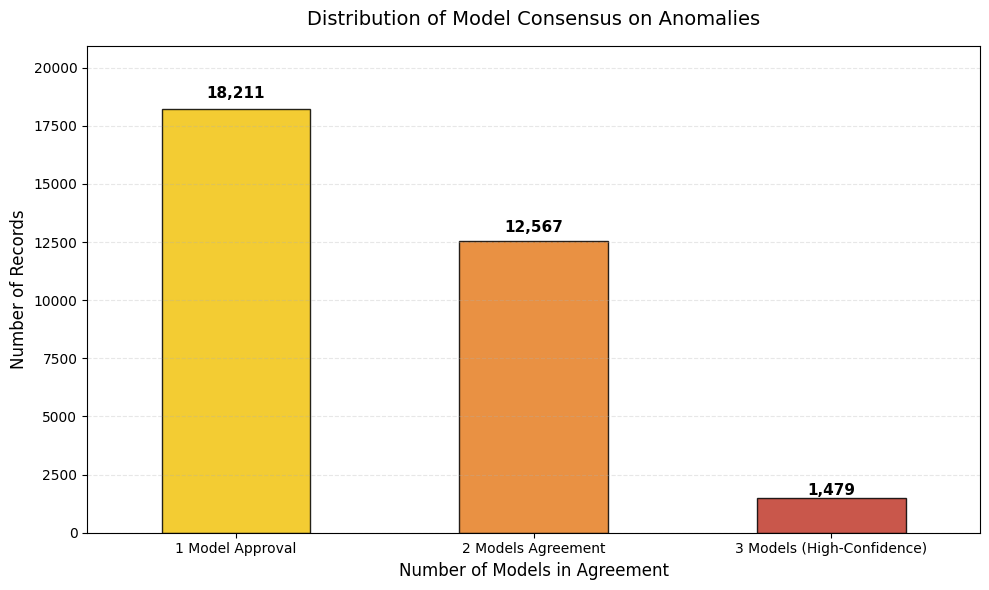

In [62]:
# 1. Prepare Data (Filtering 0-vote records)
anomaly_only_votes = df_clean[df_clean['anomaly_votes'] > 0]['anomaly_votes'].value_counts().sort_index()
total_records = len(df_clean)

# --- CONSOLE OUTPUT SECTION ---
print("\n" + "="*60)
print(f"{'MODEL CONSENSUS ANALYSIS SUMMARY':^60}")
print("="*60)
print(f"{'Category':<25} | {'Record Count':<15} | {'Share (%)':<10}")
print("-" * 60)

for vote, count in anomaly_only_votes.items():
    category_name = f"{int(vote)} Model Approval"
    percentage = (count / total_records) * 100
    print(f"{category_name:<25} | {count:<15,} | %{percentage:<10.2f}")

print("-" * 60)
total_suspicious = anomaly_only_votes.sum()
print(f"{'TOTAL SUSPICIOUS':<25} | {total_suspicious:<15,} | %{(total_suspicious/total_records)*100:<10.2f}")
print(f"{'HIGH-CONFIDENCE (3/3)':<25} | {anomaly_only_votes.get(3, 0):<15,} | %{(anomaly_only_votes.get(3, 0)/total_records)*100:<10.2f}")
print("="*60 + "\n")

# --- VISUALIZATION SECTION ---
plt.figure(figsize=(10, 6))
# Professional color palette (Yellow -> Orange -> Deep Red)
colors = ['#f1c40f', '#e67e22', '#c0392b']

anomaly_only_votes.plot(kind='bar', color=colors, edgecolor='black', alpha=0.85)

# Adding data labels on top of bars
for i, val in enumerate(anomaly_only_votes):
    plt.text(i, val + (val * 0.02), f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Distribution of Model Consensus on Anomalies', fontsize=14, pad=15)
plt.xlabel('Number of Models in Agreement', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# English labels for X-axis
plt.xticks(ticks=range(len(anomaly_only_votes)), 
           labels=['1 Model Approval', '2 Models Agreement', '3 Models (High-Confidence)'], 
           rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, anomaly_only_votes.max() * 1.15)

plt.tight_layout()
plt.savefig('outputs/figures/model_consensus_english.png', dpi=150)
plt.show()

In [63]:
en_supheliler = df_clean[df_clean['anomaly_votes'] == 3][
    ['mmsi', 'navigationalstatus', 'sog', 'cog', 'heading', 
     'shiptype', 'cog_heading_diff', 'status_speed_conflict']
].head(20)

print("=== 3 MODEL DE ANOMALİ DEDİ — EN ŞÜPHELİ GEMİLER ===")
en_supheliler

=== 3 MODEL DE ANOMALİ DEDİ — EN ŞÜPHELİ GEMİLER ===


,mmsi,navigationalstatus,sog,cog,heading,shiptype,cog_heading_diff,status_speed_conflict
161,219015373,Moored,0.0,0.0,0.0,Fishing,0.0,0
2133,219001306,Under way using engine,22.7,115.0,112.0,SAR,3.0,0
2789,219026261,Under way using engine,26.5,341.0,342.0,HSC,1.0,0
2909,219026261,Under way using engine,25.1,305.5,305.0,HSC,0.5,0
4245,209657000,Under way using engine,4.6,318.5,306.0,Tug,12.5,0
5123,219850000,Under way using engine,7.0,322.0,334.0,Tug,12.0,0
5319,219023833,Under way using engine,18.6,114.3,114.0,Pilot,0.3,0
5371,209657000,Under way using engine,7.5,317.9,311.0,Tug,6.9,0
5382,219023833,Under way using engine,18.5,109.4,110.0,Pilot,0.6,0
5517,209657000,Under way using engine,8.3,315.7,312.0,Tug,3.7,0


In [64]:
comparison = pd.DataFrame({
    'Method': ['Z-Score', 'LOF', 'Isolation Forest'],
    'Type': ['Statistical', 'Density-based', 'Distance-based'],
    'Anomaly Count': [
        df_clean['zscore_anomaly'].sum(),
        df_clean['lof_anomaly'].sum(),
        df_clean['iso_anomaly'].sum()
    ],
    'Anomaly Rate (%)': [
        round(df_clean['zscore_anomaly'].mean()*100, 2),
        round(df_clean['lof_anomaly'].mean()*100, 2),
        round(df_clean['iso_anomaly'].mean()*100, 2)
    ]
})

print("\n" + "="*65)
print(f"{'SUMMARY OF INDIVIDUAL MODEL RESULTS':^65}")
print("="*65)
print(comparison.to_string(index=False))
print("="*65)


               SUMMARY OF INDIVIDUAL MODEL RESULTS               
          Method           Type  Anomaly Count  Anomaly Rate (%)
         Z-Score    Statistical          14628              4.41
             LOF  Density-based          16577              5.00
Isolation Forest Distance-based          16577              5.00


Grafik kaydedildi: outputs/figures/individual_models\zscore_dist.png


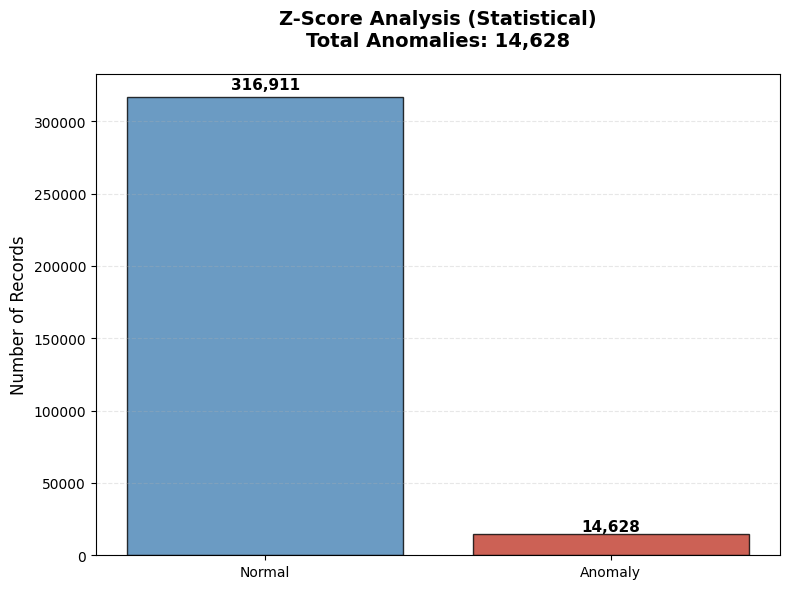

Grafik kaydedildi: outputs/figures/individual_models\lof_dist.png


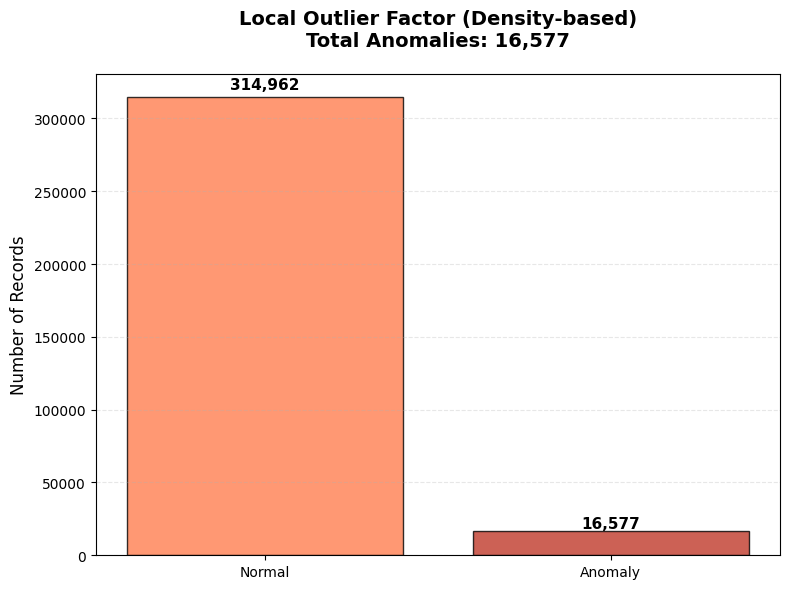

Grafik kaydedildi: outputs/figures/individual_models\iso_dist.png


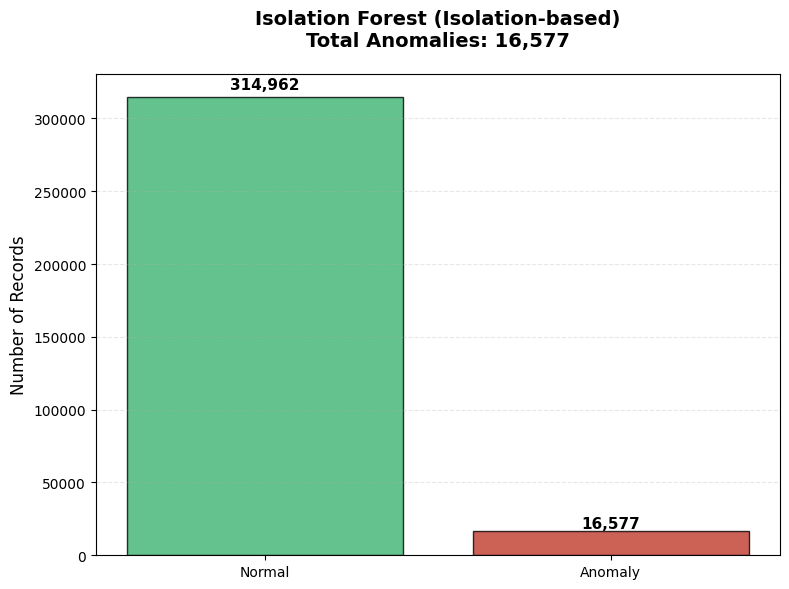

In [65]:
import matplotlib.pyplot as plt
import os

# Çıktı klasörünü kontrol et
output_dir = 'outputs/figures/individual_models'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

models = ['zscore_anomaly', 'lof_anomaly', 'iso_anomaly']
titles = ['Z-Score Analysis (Statistical)', 
          'Local Outlier Factor (Density-based)', 
          'Isolation Forest (Isolation-based)']
colors = ['steelblue', 'coral', 'mediumseagreen']
filenames = ['zscore_dist.png', 'lof_dist.png', 'iso_dist.png']

# Her model için döngü başlat ve ayrı figürler oluştur
for i, (model, title, color, fname) in enumerate(zip(models, titles, colors, filenames)):
    plt.figure(figsize=(8, 6))
    
    # Veri sayılarını al
    counts = df_clean[model].value_counts().sort_index()
    
    # Grafik çizimi
    bars = plt.bar(['Normal', 'Anomaly'], counts.values, 
                   color=[color, '#c0392b'], edgecolor='black', alpha=0.8)
    
    # Başlık ve Etiketler (İngilizce)
    plt.title(f'{title}\nTotal Anomalies: {counts[1]:,}', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Number of Records', fontsize=12)
    
    # Çubukların üzerine rakamları yazdır
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Ayrı dosya olarak kaydet
    save_path = os.path.join(output_dir, fname)
    plt.savefig(save_path, dpi=150)
    print(f"Grafik kaydedildi: {save_path}")
    
    plt.show() # Her birini ayrı ayrı ekrana basar

Ship type analysis saved: outputs/figures/ship_type_analysis\ship_type_zscore.png


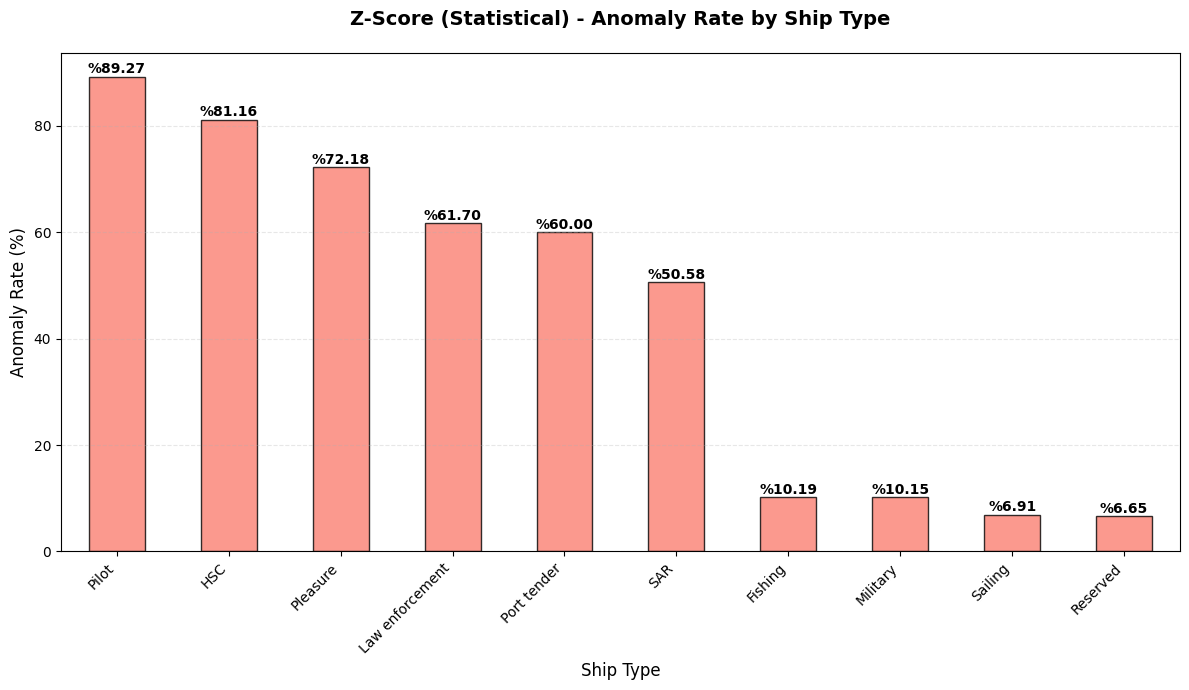

Ship type analysis saved: outputs/figures/ship_type_analysis\ship_type_lof.png


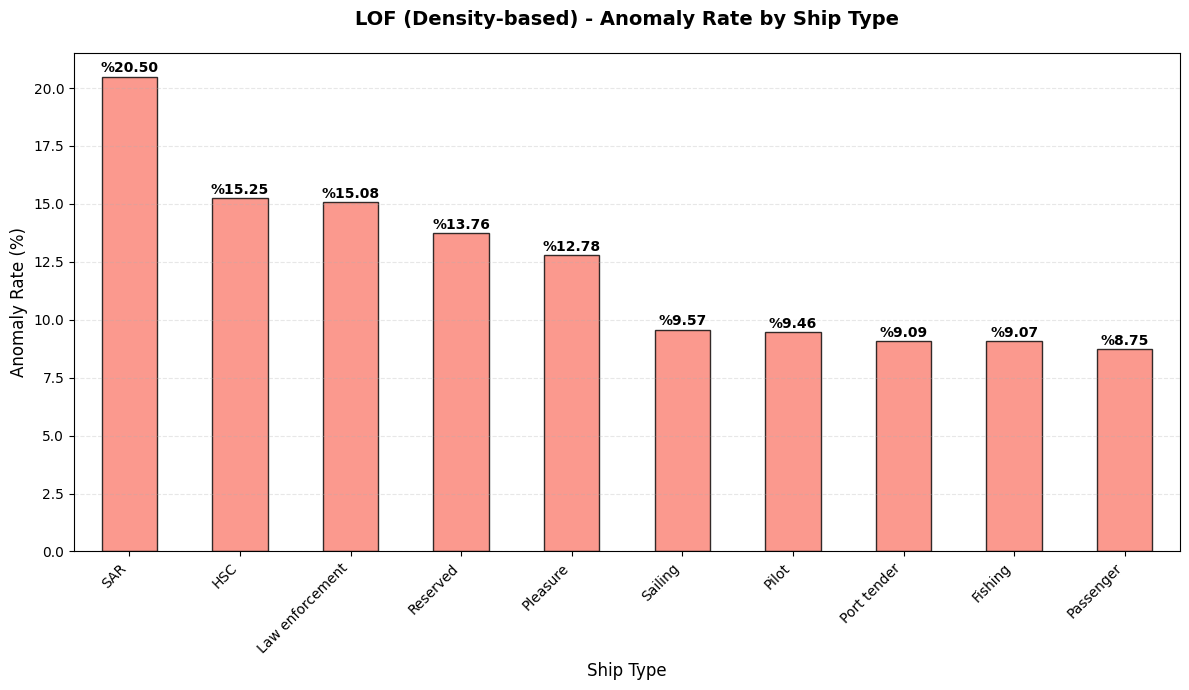

Ship type analysis saved: outputs/figures/ship_type_analysis\ship_type_iso.png


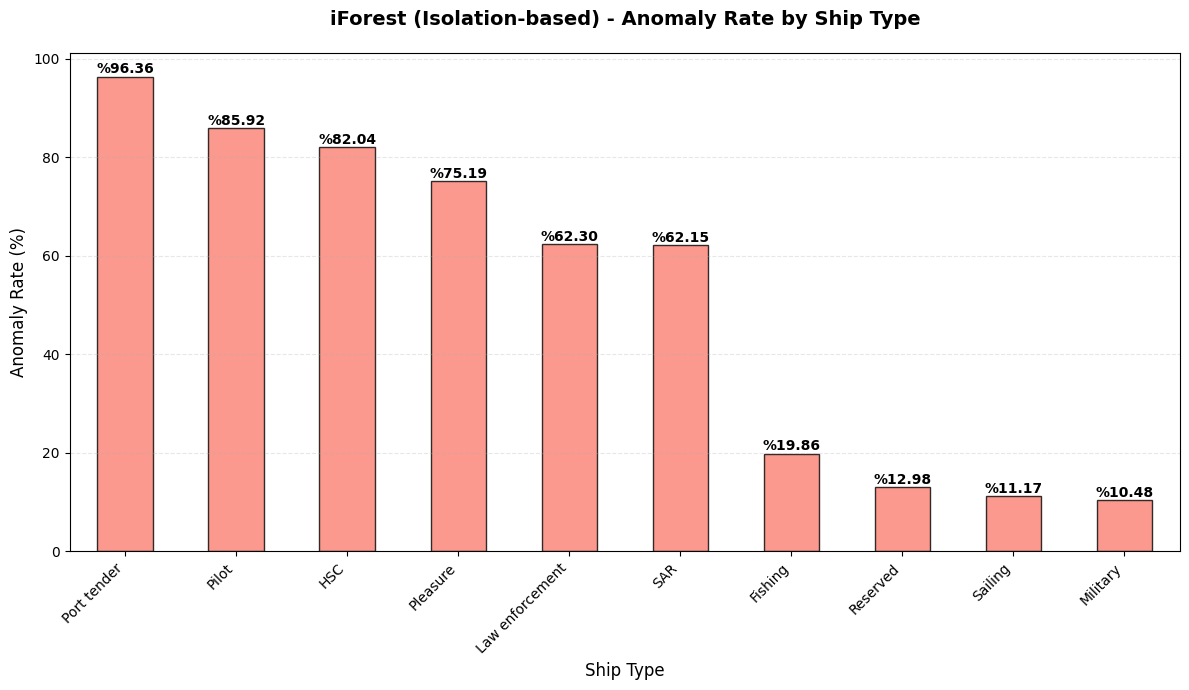

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output directory
output_dir = 'outputs/figures/ship_type_analysis'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

models = ['zscore_anomaly', 'lof_anomaly', 'iso_anomaly']
titles = ['Z-Score (Statistical) - Anomaly Rate by Ship Type', 
          'LOF (Density-based) - Anomaly Rate by Ship Type', 
          'iForest (Isolation-based) - Anomaly Rate by Ship Type']
filenames = ['ship_type_zscore.png', 'ship_type_lof.png', 'ship_type_iso.png']

for i, (model, title, fname) in enumerate(zip(models, titles, filenames)):
    plt.figure(figsize=(12, 7))
    
    # Calculate anomaly percentage per ship type
    # mean() * 100 gives the percentage of 1s in that category
    anomaly_by_type = df_clean.groupby('shiptype')[model].mean() * 100
    anomaly_by_type = anomaly_by_type.sort_values(ascending=False).head(10)
    
    # Plotting
    bars = anomaly_by_type.plot(kind='bar', color='salmon', edgecolor='black', alpha=0.8)
    
    # Add labels and title
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Ship Type', fontsize=12)
    plt.ylabel('Anomaly Rate (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add percentage labels on top of bars
    for bar in bars.patches:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'%{bar.get_height():.2f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Save each figure separately
    save_path = os.path.join(output_dir, fname)
    plt.savefig(save_path, dpi=150)
    print(f"Ship type analysis saved: {save_path}")
    
    plt.show()

Feature distribution saved: outputs/figures/feature_distribution\distribution_sog.png


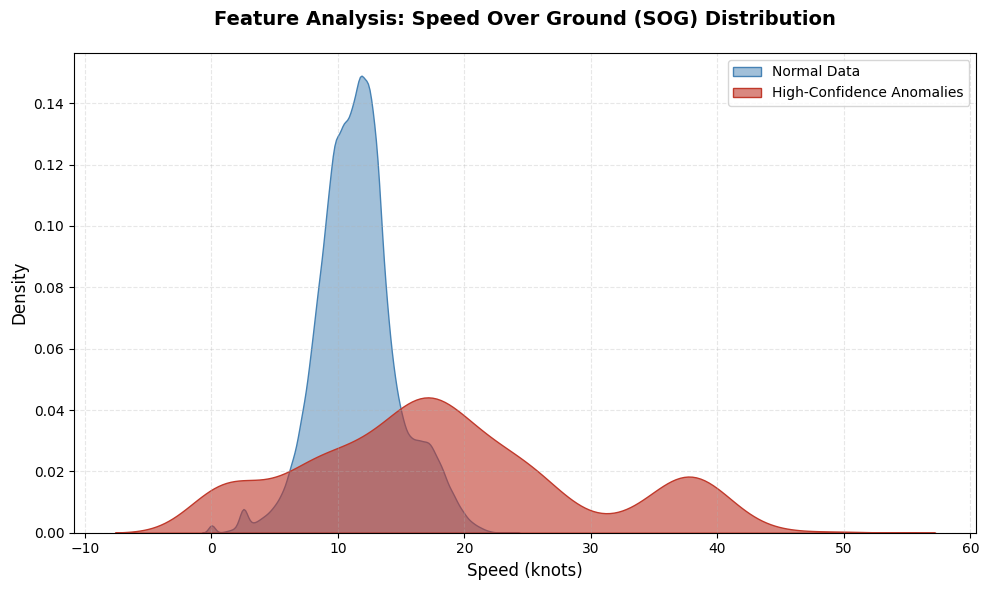

Feature distribution saved: outputs/figures/feature_distribution\distribution_cog_heading_diff.png


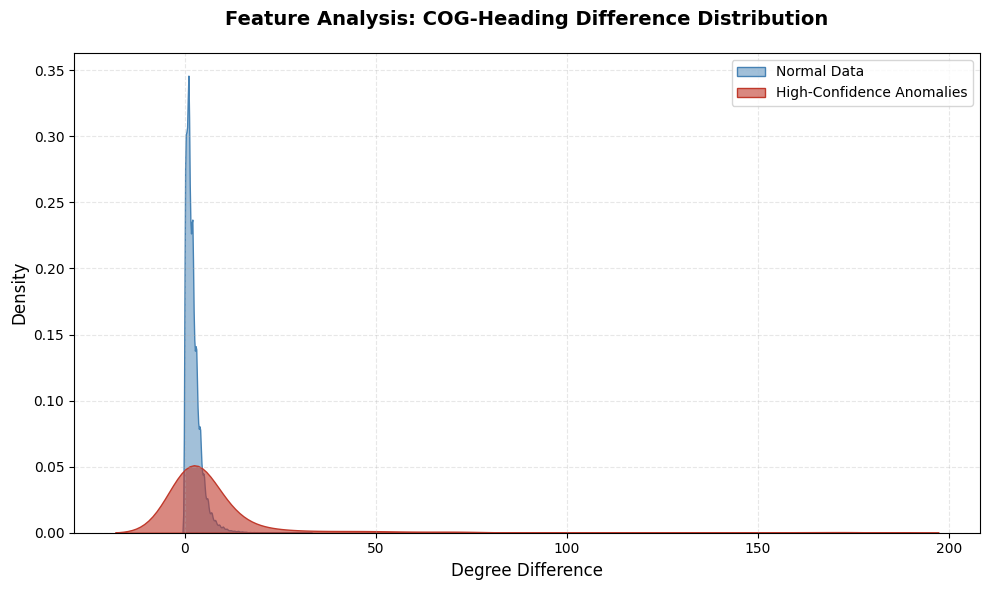

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory
output_dir = 'outputs/figures/feature_distribution'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Filter data for comparison
normal_data = df_clean[df_clean['anomaly_votes'] == 0]
high_conf_anomalies = df_clean[df_clean['anomaly_votes'] == 3]

# Define features to analyze
features = [
    ('sog', 'Speed Over Ground (SOG) Distribution', 'Speed (knots)'),
    ('cog_heading_diff', 'COG-Heading Difference Distribution', 'Degree Difference')
]

for col, title, xlabel in features:
    plt.figure(figsize=(10, 6))
    
    # Use Kernel Density Estimate (KDE) for smoother visualization
    sns.kdeplot(normal_data[col], fill=True, color='steelblue', label='Normal Data', alpha=0.5)
    sns.kdeplot(high_conf_anomalies[col], fill=True, color='#c0392b', label='High-Confidence Anomalies', alpha=0.6)
    
    # Titles and Labels
    plt.title(f'Feature Analysis: {title}', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='both', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    # Save file
    fname = f"distribution_{col}.png"
    save_path = os.path.join(output_dir, fname)
    plt.savefig(save_path, dpi=150)
    print(f"Feature distribution saved: {save_path}")
    
    plt.show()